# Импорты и to-do

In [1]:
# from langchain_gigachat import GigaChat
from langgraph.graph import MessagesState
from langchain_core.messages import AIMessage, HumanMessage, SystemMessage
from langgraph.graph import START, StateGraph, END
from langgraph.prebuilt import tools_condition, ToolNode
from IPython.display import Image, display
from langgraph.checkpoint.memory import MemorySaver
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate
from typing import Annotated, List, Tuple, Union, Literal, Dict
from typing_extensions import TypedDict
from pydantic import BaseModel, Field
import os
from dotenv import load_dotenv
from langchain_core.documents import Document
from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import FAISS
from langchain.retrievers import BM25Retriever, EnsembleRetriever
from langchain_community.document_loaders.csv_loader import CSVLoader
import pandas as pd
import re
# Загружаем переменные окружения из .env файла
load_dotenv()

# # Получаем API-ключ из переменной окружения
creds = os.getenv('credentials')
token = os.getenv('OPENAI_API_KEY')

from tabulate import tabulate

to-do:\
перейти на более красивый нодовый граф\
понять как работает Command\
ДОБАВИТЬ бд сценариев, планов и функции для получения и записи планов в неё \
выбирать функции вот так https://langchain-ai.github.io/langgraph/how-tos/many-tools/ \
взаимодействие с тред_айди и конфигом внутри тулов\
суммаризация?\
добавить slqlite saver вместо меморисейвера\
добавить storage для персонализации + бд с персинфой

# Моки сценариев и функций

In [2]:
import pandas as pd
data = {
    'Название сценария': ['Потеря/сломалась банковская карта','Сценарий определения погоды'],
    'Условия входа': [
        """Запрос пользователя связан с одной из перечисленных тем:
        1) Потеря карты 
        2) Сломалась карта
        Это обязательные уловия для входа в сценарий, если карта НЕ утрачена и НЕ сломана, то в этот сценарий входить нельзя.
        """,
        """Запрос пользователя связан с одной из перечисленных тем:
        1) погода
        2) осадки
        3) атмосферное давление""",
    ],
    'Описание сценария': ["""Сценарий потери банковской карты:
Если пользователь потерял или сломал банковскую карту, есть 4 основных этапа:
1) Получи список карт пользователя, используя функцию get_user_cards.
2) Предложи заблокировать эту карту.
3) Предложи пользователю перевыпустить карту. 
4) Предложи пользователю доставить карту."""
        ,
        """
        В рамках сценария опрежделения погоды сперва необходимо определить в какой именно местности необходимо уточнить погоду.
        Если Пользователь сразу назвал необходимое место (например: "Скажи погоду в Москве") то определи с помощью функции factual_questions() погоду в названной пользователем местности.
        В случае, если не удается однозначно определить необходимую местность, то доуточни у пользователя, а затем вызови функцию factual_questions() для текущей местности.
        """
    ],
    'Справочная информация': [
        """Карта Momentum — это специальная карта, которая может предлагать дополнительные преимущества, такие как кэшбэк, бонусные баллы или специальные скидки на покупки.
        Она предназначена для людей, которые часто используют свои карты и хотят получать дополнительные выгоды от своих трат.
        Самокат - сервис доставки.
        """,
        """
        Справочный информации нет, пользуйся собственными знаниями.
        """
    ]
}
df = pd.DataFrame(data)

In [3]:
df

,Название сценария,Условия входа,Описание сценария,Справочная информация
0,Потеря/сломалась банковская карта,Запрос пользователя связан с одной из перечисл...,Сценарий потери банковской карты:\nЕсли пользо...,"Карта Momentum — это специальная карта, котора..."
1,Сценарий определения погоды,Запрос пользователя связан с одной из перечисл...,\n В рамках сценария опрежделения погод...,"\n Справочный информации нет, пользуйся..."


In [4]:
choose_question_rag_prompt = """
Роль:
Ты — агент, выбирающий наиболее подходящий вопрос к вопросу пользователя.

Задание:
1. Проанализируй предоставленные вопросы и вопрос пользователя.
2. Верни наиболее похожий вопрос, либо ответь что похожего вопроса нет.

Предоставленные вопросы:
{context}

Вопрос пользователя:
{question}

Твоя задача — вернуть из предоставленных вопросов вопрос наиболее похожий на вопрос пользоватeля, либо сообщить об отсутствии такого вопроса (верни 'no').
"""

choose_question_rag_template = ChatPromptTemplate.from_template(choose_question_rag_prompt)

question_choose_agent = choose_question_rag_template | ChatOpenAI(
    model="gpt-4o-mini", temperature=0
)

In [5]:
def get_embeddings():
    model_name = "sentence-transformers/paraphrase-multilingual-mpnet-base-v2"
    model_kwargs = {'device': 'cpu'}
    encode_kwargs = {'normalize_embeddings': False}
    embedding = HuggingFaceEmbeddings(
        model_name=model_name,
        model_kwargs=model_kwargs,
        encode_kwargs=encode_kwargs
        )
    return embedding

def prep_bd():
    file_path = '/Users/grigoriy/Desktop/work'
    vector_store_loaded = FAISS.load_local(folder_path=file_path, embeddings=get_embeddings(), allow_dangerous_deserialization= True)
    loaded_retriever = vector_store_loaded.as_retriever(search_kwargs={'k': 3}, search_type="mmr")
    return loaded_retriever

In [6]:
# Нужно будет придумать логику бинда функций для разных задач, мы же не будем биндить сразу все доступные функции

# Set up the tool
from langchain_core.tools import tool
from langgraph.prebuilt import ToolNode
from langchain_community.tools.tavily_search import TavilySearchResults

@tool
def get_user_cards():
    """Обзор списка доступных пользователю карт. Получение списка карт пользователя"""
    cards_name = ['МИР***1234', 'VISA***2345','MASTERCARD***3456']
    # Логика для получения списка карт пользователя через API или другой механизм.
    return f'Список доступных карт: {cards_name}'

@tool
def block_card(card_name: str):
    """Заблокировать карту"""
    # Логика для блокировки карты через API или другой механизм
    return f"Карта {card_name} успешно заблокирована."

@tool
def reissue_card(card_name: str, new_card_type: str = "Momentum"):
    """Перевыпустить карту. Например, можно выбрать карту типа Momentum или карту постоянного пользования."""
    # Логика перевыпуска карты
    return f"Перевыпущена карта типа {new_card_type}."

@tool
def deliver_card(delivery_method: str = "Самокат"):
    """Организовать доставку карты. Можно выбрать способ доставки: 'Самокат' или самовывоз."""
    if delivery_method.lower() == "самокат":
        return "Карта будет доставлена с помощью службы доставки 'Самокат'."
    elif delivery_method.lower() == "самовывоз":
        return "Вы можете забрать карту в пункте самовывоза."
    else:
        return "Выберите один из доступных методов доставки: 'Самокат' или 'Самовывоз'."

# ПОКА ЗАКОМЕНТИЛ НЕ ЮЗАЮТСЯ И МЕШАЮТ
# @tool
# def card_balance(card_name: str, balance):
#     """Узнать баланс на карте"""
#     # Логика для получения баланса карты через API или другой механизм
#     return f"На карте {card_name} есть {balance} средств."

# @tool
# def transefer_money(card_name: str, card_name_to: str, balance):
#     """Перевести деньги с карты на карту"""
#     # Логика для перевода денег с карты на карту через API или другой механизм
#     return f"Переведено {balance} с  карты {card_name} на карту {card_name_to}."

# @tool
# def destination_weather(destinatio: str):
#     """Определение погоды в данной местности"""
#     # Логика для определения погоды в данной местности через API или другой механизм
#     return f"В {destinatio} следующая погода."

@tool
def factual_questions(user_question):
    """Используй search_tool когда нужно ответить на фактологический вопрос."""
    search_tool = TavilySearchResults(
                    max_results=5,
                    # include_answer=True,
                    # include_raw_content=True,
                    # include_images=False,
                    # search_depth="advanced",
                    # include_domains = []
                    # exclude_domains = []
                )
    return search_tool.invoke(user_question)

@tool
def sberbank_question(bank_question):
    """Ответ на вопросы по продуктам и услугам Сбербанка."""

    pf = pd.read_csv('FAQ.csv')

    class StateRAG(TypedDict):
        question: str
        context: List[Document]
        answer: str

    def retrieve_question(state: StateRAG):
        retrieved_docs = prep_bd().invoke(state["question"])
        return {"context": retrieved_docs}
    
    def map_questions_and_answer(state: StateRAG):
        docs_content = "\n\n".join(doc.page_content for doc in state["context"])
        question = question_choose_agent.invoke({"context": docs_content, "question": state["question"]})
        print(question)
        # print(question)
        if question.content.lower() not in ['no',"'no'"]:
            q = pf.loc[pf['Вопрос'] == question.content[8:], 'Ответ'].values[0]
            # print(q)
            # answer = ans.invoke({"question": state["question"], "context": q})
            return {'answer':q}
        return {"answer": 'у меня нет ответа на ваш вопрос'}

    graph_builder = StateGraph(StateRAG).add_sequence([retrieve_question, map_questions_and_answer])
    graph_builder.add_edge(START, "retrieve_question")
    graph = graph_builder.compile()
    graph
    return f'{graph.invoke({"question": bank_question})['answer']}'


tools = [get_user_cards, block_card, reissue_card, deliver_card, factual_questions, sberbank_question]#card_balance, transefer_money, 
tool_node = ToolNode(tools)
memory = MemorySaver()


# планировщики сценарный и динамический (чисто на функциях)

In [7]:
def plan_scenar(scen,mess,temp=0):
    plan_tmp = """
    Роль:
    Ты — агент-планировщик. Твоя задача — разработать подробный и последовательный план действий для решения проблемы, исходя из предоставленного сценария и доступных функций. План будет передан агенту-исполнителю для выполнения.

    Задание:
    Тебе нужно создать план, основываясь на сценариях и списке доступных функций (используй только те функции, которые нужны для выполнения сценария).

    Сценарии: {scenario}

    Диалог c пользователем: {messages}

    Твой план должен соответствовать следующим требованиям:
    1. Разработай последовательность шагов, которая максимально эффективно решает проблему, учитывая сценарий и доступные функции.
    2. Определи возможные пробелы в информации, которые могут потребовать уточнения от пользователя, и составь план так, чтобы на важных этапах ты мог запросить дополнительные разъяснения.
    3. Запроси разрешение у пользователя на выполнение критичных операций, таких как изменение данных или выполнение действий, которые могут повлиять на дальнейшие шаги. Если в сценарии написано, что запрашивать разрешение не надо - не заправишивай, сценарии всегда в приоритете.
    4. Учитывай, что агент-исполнитель будет подробно описывать каждый шаг, который он будет выполнять, а также будет указывать, какие функции использует на каждом этапе. Поэтому убедись, что каждый этап описан максимально четко.
    5. Если какие-то шаги требуют предварительных условий или зависимостей, укажи это.

    Итоговый формат плана:
    1) Что должен сделать агент, какие ему использовать функции(если необходимо).
    2) Что должен сделать агент, какие ему использовать функции(если необходимо).
    3) Что должен сделать агент, какие ему использовать функции(если необходимо).
    ... и так далее.
    """
    scen_prompt = ChatPromptTemplate.from_template(plan_tmp)
    model = ChatOpenAI(model="gpt-4o-mini", api_key = token, temperature=temp)
    model = model.bind_tools(tools, parallel_tool_calls=False)
    chain = scen_prompt | model
    return chain.invoke({'scenario':scen, 'messages':mess})

# динамический планер
def plan_dinamic(mess, temp=0):
    plan_atom = """
    Роль:  
    Ты — агент-планировщик. Твоя задача — составить четкий и эффективный план действий для решения текущей потребности пользователя, опираясь на доступные функции. Этот план будет передан агенту-исполнителю для выполнения.  

    Задание:  
    1. Анализируй потребности пользователя, исходя из контекста диалога.  
    2. Создай последовательный план, включающий только те шаги и функции, которые необходимы для удовлетворения текущей потребности. Не добавляй лишних шагов или функций, если в этом нет необходимости.  
    3. Решай только текущую задачу — не планируй действия, выходящие за рамки запроса.  

    Диалог с пользователем (контекст задачи):  
    {messages}  

    Требования к плану:  
    1. **Простые запросы:** Если запрос носит общий характер (например, приветствие или вопрос о настроении), верни краткий план, например: *"Просто поддерживай беседу с пользователем."*  
    2. **Эффективность:** Составляй план так, чтобы он решал задачу с минимальным числом шагов.  
    3. **Критические операции:** Если действия требуют изменений данных или могут повлиять на последующие шаги, обязательно добавь шаг, где агент запрашивает разрешение пользователя.  
    4. **Ясность:** Убедись, что каждый шаг описан четко и включает:
    - Что нужно сделать.
    - Какую функцию задействовать (если необходимо).  
    5. **Зависимости:** Укажи предварительные условия или зависимости для выполнения каждого шага, если они есть.

    Формат плана:  
    1) [Описание действия]. Функция: `[название функции]` (если необходимо).  
    2) [Описание действия]. Функция: `[название функции]` (если необходимо).  
    3) [Описание действия]. Функция: `[название функции]` (если необходимо).  
    ... и так далее.  

    Пример задачи:  
    Запрос пользователя: "Узнай погоду в Москве и сообщи мне в удобной форме."  

    Пример плана:  
    1. Узнать у пользователя где именно в Москве его интересует погода. 
    2. Получить данные о погоде в данной местности. Функция: `factual_questions`. 
    3. Сообщить пользователю результат.
   
    Пример задачи:  
    Запрос пользователя: "Какие условия по кредитной СберКарте?"  

    Пример плана:  
    1. Получить данные о кредитной СберКарте. Функция: `sberbank_question`. 
    2. Сообщить пользователю результат.

    Составь план на основе текущего диалога.
    """

    atom_prompt = ChatPromptTemplate.from_template(plan_atom)
    model = ChatOpenAI(model="gpt-4o-mini",api_key = token, temperature=temp)
    model = model.bind_tools(tools, parallel_tool_calls=False)
    chain = atom_prompt | model
    return chain.invoke({'messages':mess})
# 5. На общие фразы (например, «привет», «пока», «как дела», «как настроение») не нужно создавать большие планы. В таких случаях достаточно вернуть план типа: «Просто болтай с пользователем».

# Graders

In [8]:

#грейдер оценка по плану\нет Пока в стопе
# class GradePlan(BaseModel):
#     """Релевантен ли запрос текущему плану"""

#     binary_score: Literal["yes", "no"] = Field(
#         ...,
#         description="Релевантен ли запрос плану yes или no",
#     )

# grader_prompt = """ 
# Роль:
# Ты агент оценивающий релевантность запроса пользователя по отношению к текущему плану в два этапа:

# Этап 1: Оценка релевантности запроса текущему плану
# Проанализируй запрос пользователя в контексте текущего плана. Если запрос содержит информацию, связанную с этим планом (например, этапы, задачи или темы, упомянутые в плане), оцени его как релевантный (yes).
# Обрати внимание, что пользователь может уже пройти часть плана, поэтому внимательно проверь соответствие запроса каждому этапу.

# Дай бинарную оценку:
# yes — запрос релевантен текущему плану
# no — запрос не связан с текущим планом

# Диалог с пользователем:
# (Основное внимание удели последним репликам пользователя)
# {messages}

# Текущий план:
# {plan}

# Если твой ответ no сразу верни его, если твой ответ yes переходи ко второму этапу.

# Этап 2: Проверка на выполнение условий входа.
# Условия входа:
# {enter}
# Если запрос пользователя не совпадает с условием входа верни yes, если запрос пользователя совпадает с условием входа верни no.
# """

# planner_grader_prompt = ChatPromptTemplate.from_template(grader_prompt)

# planner_grader = planner_grader_prompt | ChatOpenAI(
#     model="gpt-4o-mini", temperature=0, api_key = token
# ).with_structured_output(GradePlan, include_raw=True)



#грейдер соблюдения условий входа

# class GradeEnter(BaseModel):
#     """Соблюдены ли условия входа в сценарий"""

#     name: str = Field(
#         ...,
#         description="Соблюдены ли условия входа в сценарий, если соблюдены верни название сценария, если не соблюдены верни 'no'",
#     )

grader_scen_prompt = """
Задача: Ты оцениваешь есть ли подходящие условия входа в сценарий для запроса пользователя.

Проанализируй запрос пользователя и сценарий с его условиями входа. Если по запросу можно войти в данный сценарий верни название этого сценария. В противном случае верни 'no'.

Информация для работы:
Запрос пользователя:
{messages}
Название сценария и условия входа:
{conditions}

В твоём ответе должно быть только название сценария либо 'no'.

Пример 1:
Пользователь: Завтра будет дождь?
Название сценария и словия входа:
'Потеря/сломалась банковская карта':'Запрос пользователя связан с одной из перечисленных тем: \n        1) потерялась карта \n        2) потерялся объект, в котором находилась карта \n        3) сломалась карта',
'Сценарий определения погоды':'Запрос пользователя связан с одной из перечисленных тем:\n        1) погода\n        2) осадки\n        3) атмосферное давление\n'

Сценарий определения погоды

Пример 2:
Пользователь: Потерял куртку, что делать?
Название сценария и словия входа:
'Потеря/сломалась банковская карта':'Запрос пользователя связан с одной из перечисленных тем: \n        1) потерялась карта \n        2) потерялся объект, в котором находилась карта \n        3) сломалась карта',
'Сценарий определения погоды':'Запрос пользователя связан с одной из перечисленных тем:\n        1) погода\n        2) осадки\n        3) атмосферное давление\n'

no
"""

planner_grade_scen_prompt = ChatPromptTemplate.from_template(grader_scen_prompt)

planner_scen_grader = planner_grade_scen_prompt | ChatOpenAI(
    model="gpt-4o-mini", temperature=0,api_key = token)#.with_structured_output(GradeEnter, include_raw=True)


# grader статусы

# class GraderStatus(BaseModel):
#     """Статус плана"""

#     completion_score: Literal['run', 'pause','done'] = Field(
#         ...,
#         description="Оценка статуса плана: 'run' — текущий план, 'done' — план завершён, 'pause' — приостановлено выполнение плана"
#     )

completion_grader_prompt = """
Роль:
Ты — агент, анализирующий текущий статус каждого плана на основе списка планов и диалога с пользователем и определяющий, какие пункты уже выполнены, либо возвращающий статус `done`, если все пункты завершены или потребность пользователя решена.

Задание:
1. Проанализируй все планы и историю диалога с пользователем.
2. Верни JSON, в котором для каждого `plan_id`:
   - Если план выполнен полностью, укажи `"plan_status": "done"` и заполни соответствующие `"completed_items"`.
   - Если план выполняется или выполнен частично, верни `"completed_items"` — список пунктов, которые уже выполнены. (выполненных пунктов не может быть больше чем первоначально было в плане)
     
Формат ответа:
{{
    "1": {{
        "plan_status": "done",
        "completed_items": ["1)", "2)", "3)"]
    }},
    "2": {{
        "plan_status": "",
        "completed_items": ["1)"]
    }},
    "3": {{
        "plan_status": "",
        "completed_items": ["1)", "2)"]
    }}
}}

Таблица с планами:
{all_plans}

Диалог с пользователем:
{messages}

Твоя задача — вернуть только корректный JSON с данными для каждого плана.
"""

completion_status_prompt_template = ChatPromptTemplate.from_template(completion_grader_prompt)

completion_status_agent = completion_status_prompt_template | ChatOpenAI(
    model="gpt-4o-mini", temperature=0
)#.with_structured_output(GraderStatus)#, include_raw=True)

#grader old_plans

class PlanEvaluator(BaseModel):
    """Проверка, удовлетворяет ли запросу пользователя один из существующих планов"""

    result: str = Field(
        ...,
        description="Верни 'NO', если подходящего плана нет, или 'id плана', если один из планов подходит.",
    )

check_plan_from_cache_template = """
Роль: Эксперт по сопоставлению запросов пользователя с существующими планами.

Задача: Проанализировать запрос пользователя и определить наиболее подходящий план из имеющихся, либо вернуть 'no' в случае отсутсвия такого плана.

Инструкции:
1. Внимательно изучите запрос пользователя и каждый план в словаре.
2. Внимательно сопоставьте каждый этап плана с запросом пользователя.

Фьюшот-примеры:

Пример 1:
Запрос пользователя: "Моментум"
Планы:
{{
    'plan_id:1, plan_text: 1) Получить список карт пользователя. 2) Уточнить, какая карта потеряна. 3) Заблокировать карту. 4) Перевыпустить карту на Momentum либо постоянного пользования. 5) Организовать доставку новой карты доставкой 'Самокат' либо самовывозом.',
    'plan_id:2, plan_text: 1) Узнать, где потерян предмет. 2) Поискать в посещенных местах. 3) Сообщить в службу находок.'
}}
Результат: "1"

Пример 2:
Запрос пользователя: "Хочу яблок"
Планы:
{{
    'plan_id:1, plan_text: 1) Получить список карт пользователя. 2) Уточнить, какая карта потеряна. 3) Заблокировать карту. 4) Перевыпустить карту. 5) Организовать доставку новой карты.',
    'plan_id:2, plan_text: 1) Узнать у пользователя, где именно он потерял куртку. 2) Предложить поискать в местах, которые он сегодня посещал. 3) Предложить сообщить о потере в службу находок.'
}}
Результат: "NO"
Пример 3:
Запрос пользователя: "Давай самокатом"
Планы:
{{
    'plan_id:1, plan_text: 1) Получить список карт пользователя. 2) Уточнить, какая карта потеряна. 3) Заблокировать карту. 4) Перевыпустить карту на Momentum либо постоянного пользования. 5) Организовать доставку новой карты доставкой 'Самокат' либо самовывозом.',
    'plan_id:2, plan_text: 1) Узнать, где потерян предмет. 2) Поискать в посещенных местах. 3) Сообщить в службу находок.'
    'plan_id:3, plan_text: 1) Узнать, какую начинку для пиццы предпочитает пользователь. 2) Уточнить размер пиццы. 3) Организовать доставку.'
}}
Результат: "1"

Текущий запрос пользователя: {message}
Доступные планы: {plans_dict}

Требования к ответу:
- Верните "NO", если подходящего плана нет
- Верните "id плана", если план полностью или частично покрывает запрос
- Особое внимание: для потери карты используйте план, связанный именно с картами

Дополнительное условие: 
- Если пользователь потерял карту, используйте план, связанный с картами
- Если план связан только с поиском предмета, но не с картой - верните "NO"

Формат ответа: Только ID плана или "NO"
"""

check_plan_from_cache_prompt = ChatPromptTemplate.from_template(check_plan_from_cache_template)

check_plan_grader = check_plan_from_cache_prompt | ChatOpenAI(
    model="gpt-4o-mini", temperature=0, api_key=token
).with_structured_output(PlanEvaluator)

# grader summary

summary_prompt_template = """
Роль: Эксперт по составлению кратких резюме планов.

Требования к резюме:
- Максимальная информативность
- Не более 2 предложений
- Фокус на ключевых этапах
- Использование глаголов действия

Примеры:

Пример 1:
План:
1) Узнать у пользователя, где именно он потерял куртку (например, в магазине, на улице и т.д.). 
2) Предложить пользователю поискать в местах, которые он сегодня посещал.
3) Предложить пользователю сообщить о потере куртки в соответствующие службы (например, в полицию или в службу находок).

Ответ:
План, позволяющий решить проблему потери куртки.

Пример 2:
План:
1) Агент должен получить список карт пользователя, используя функцию `get_user_cards`. 
2) После получения списка карт, агент должен уточнить у пользователя, какая именно карта потеряна или сломана. 
3) После того как пользователь укажет потерянную или сломанную карту, агент должен предложить заблокировать эту карту, используя функцию `block_card`. 
4) После успешной блокировки карты, агент должен предложить пользователю перевыпустить карту, используя функцию `reissue_card`. 
5) После того как карта будет перевыпущена, агент должен предложить организовать доставку новой карты, используя функцию `deliver_card`. 
6) Агент должен завершить процесс, подтвердив пользователю, что все шаги выполнены.

Ответ:
План комплексной замены утраченной банковской карты, включающий определение, блокировку, перевыпуск и доставку новой карты.

Текущий план:
{plan}

Формат ответа: Краткое связное описание плана, раскрывающее основную последовательность действий.
"""

summary_prompt = ChatPromptTemplate.from_template(summary_prompt_template)

summary = summary_prompt | ChatOpenAI(
    model="gpt-4o-mini", temperature=0
)



In [9]:
# экзекьютор
from langchain_core.runnables import RunnablePassthrough

def get_executor(plan):
    executor_prompt = ChatPromptTemplate.from_messages(
        [
            ("system", f"""Ты — эмпатичный агент-исполнитель. Твоя задача — выполнить план действий, который ты получил от агента-планировщика. Следуй по плану, при этом уточняй информацию или предпринимай дополнительные шаги, если это необходимо.
    План:
    {plan}
    В процессе выполнения задач, если на каком-то этапе тебе не хватает информации или неясности по действиям, уточни их у пользователя.
    Пожалуйста, начни выполнение задач, следуя указанному плану. В конце своего ответа добавь "SYS": и опиши какой этап плана ты только что выполнил, также опиши свои действия (например какие функции ты использовал) и что ты будешь делать дальше.
    Информацию о функциях можно передавать только после SYS.
    """),
            ("human", "{input}"),
        ]
    )
    model = ChatOpenAI(model="gpt-4o-mini",api_key = token)
    model = model.bind_tools(tools, parallel_tool_calls=False)
    chain = {"input": RunnablePassthrough()} | executor_prompt | model
    return chain

# Вспомогательные функции для графа

In [ ]:
# Help functions for graph
def add_generated_plan(plan_text, start_mes, completed_items=None, plan_status="start"): # возможно эта функция не нужна, потом через стейт add
    global CACHE_DF

    new_id = CACHE_DF['plan_id'].max() + 1 if not CACHE_DF.empty else 1

    new_row = {
        'plan_id': new_id,
        'plan_text': plan_text,
        'plan_status': plan_status,
        'completed_items': completed_items,
        'start_mes':start_mes,
        'summary':summary.invoke({plan_text}).content
    }

    CACHE_DF = pd.concat([CACHE_DF, pd.DataFrame([new_row])], ignore_index=True)

def display_dataframe_pretty(df, title="Проверяем датафрейм"):
    print("\n" + "-" * 40 + f" {title} " + "-" * 40)
    table = tabulate(df, headers="keys", tablefmt="grid", showindex=False)
    print(table)
    print("-" * (82 + len(title)) + "\n")

def display_result_with_border(result, title="Результат проверки"):
    print("\n" + "-" * 40 + f" {title} " + "-" * 40)
    print(f"{result}")
    print("-" * (80 + len(title)) + "\n")

def clean_dialogue(dialogue):
    dial = dialogue.copy()
    """
    Убирает части текста, начинающиеся с 'SYS', из сообщений в диалоге.
    
    Args:
        dialogue (list of str): Список строк с сообщениями диалога.
    
    Returns:
        list of str: Очищенный список строк.
    """
    return [re.sub(r'\n\nSYS:.*', '', message) for message in dial]

def extract_relevant_messages(messages):
    cleaned_messages = []
    for message in messages:
        if message.type in ["human", "ai",'tool','tools']:
            # Убираем все после 'SYS:' в контенте AIMessage
            content = message.content#.split("\n\nSYS:")[0]
            cleaned_messages.append(f"{message.type}: {content}")
    return cleaned_messages

# Функция для обновления статуса через агента  
def update_plan_status_with_agent2(df, messages):
    # Формируем контекст для промпта
    all_plans = {f"plan_id:{row['plan_id']}, plan_text: {row['plan_text']}" for _, row in df.iterrows()}
    # all_plans = df[['plan_id','plan_text']].to_string(index=False, header=True)
    message_context = clean_dialogue(extract_relevant_messages(messages=messages))

    # Вызываем агента
    result = completion_status_agent.invoke(
        {'all_plans': all_plans,
         'messages': message_context}
    )

    # Извлекаем JSON-строку, удаляя обрамляющие символы
    content = result.content.strip('```json').strip().strip('```')

    # Обновляем датафрейм на основе выполненных пунктов
    plan_updates = eval(content)  # Преобразуем JSON-строку в словарь

    for id_plan, data in plan_updates.items():
        plan_id = int(id_plan)  # Преобразуем строковый ключ в число
        if data.get('plan_status') == 'done':
            # Если статус done, обновляем план
            df.loc[df['plan_id'] == plan_id, 'plan_status'] = 'done'
        elif 'completed_items' in data:
            # Если есть выполненные пункты, обновляем соответствующую колонку
            df.loc[df['plan_id'] == plan_id, 'completed_items'] = ', '.join(data['completed_items'])

    return df

#status without agent
def update_plan_status(df, cur_plan_id):
    """
    Обновляет статусы в датафрейме:
    - Все статусы, кроме "done", меняются на "pause".
    - Для строки с plan_id == cur_plan_id устанавливается статус "run".
    
    :param df: DataFrame с колонками "plan_id" и "plan_status".
    :param cur_plan_id: ID плана, который должен быть переведен в статус "run".
    :return: Обновленный DataFrame.
    """
    # Обновляем все статусы, кроме "done", на "pause"
    df.loc[df['plan_status'] != 'done', 'plan_status'] = 'pause'
    
    # Устанавливаем статус "run" для строки с текущим планом
    df.loc[df['plan_id'] == cur_plan_id, 'plan_status'] = 'run'
    
    return df

def get_curr_plan_id(df, plan):
    # Фильтруем датафрейм по совпадению plan_text с переданным текстом
    matching_plans = df[df['plan_text'] == plan]
    
    # Если совпадений нет, вернуть None
    if matching_plans.empty:
        return None

    # Возврат идентификатора первого совпавшего плана
    return matching_plans['plan_id'].iloc[0]

# Для аутпута тестов
def _print_event(event: dict, _printed: set, max_length=1500):
    current_state = event.get("dialog_state")
    if current_state:
        print("Currently in: ", current_state[-1])
    message = event.get("messages")
    if message:
        if isinstance(message, list):
            message = message[-1]
        if message.id not in _printed:
            msg_repr = message.pretty_repr(html=True)
            if len(msg_repr) > max_length:
                msg_repr = msg_repr[:max_length] + " ... (truncated)"
            print(msg_repr)
            _printed.add(message.id)


# Сам граф

In [11]:
from langgraph.graph.message import add_messages
from langchain_core.messages import HumanMessage, AIMessage, ToolMessage
from langchain_core.runnables.config import RunnableConfig
from langgraph.types import Command

class ComplexState(TypedDict):
    plan: List[str]
    messages: Annotated[list[HumanMessage | AIMessage | ToolMessage], add_messages]
    vremya_dengi: dict[str,str]
    df: dict



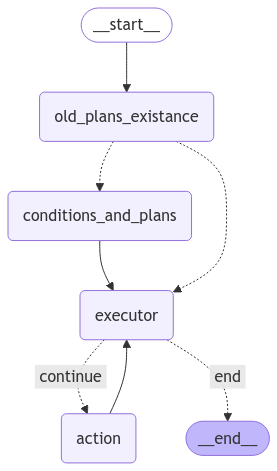

In [12]:
# Define the function that determines whether to continue or not. Вызывать тулзу или нет. Вроде есть готовое решение tool_conditions или как-то так
def should_continue(state):
    messages = state["messages"]
    last_message = messages[-1]
    # If there is no function call, then we finish
    if not last_message.tool_calls:
        return "end"
    # Otherwise if there is, we continue
    else:
        return "continue"

def node_old_plan_exist(state) -> Command[Literal["conditions_and_plans", "executor"]]:
    # print('old')
    plan = state.get("plan")
    plans_dict = {f"plan_id:{row['plan_id']}, plan_text: {row['plan_text']}" for _, row in CACHE_DF.iterrows()}
    # print(plans_dict)
    # smt = df['Условия входа'].to_list()
    old_plan_score = check_plan_grader.invoke({"plans_dict":plans_dict,"message": state['messages'][-1]}) #"conditions":smt,
    # display_result_with_border(old_plan_score, "Результат проверки на наличие в DataFrame")
    if plan is None or old_plan_score.result.lower() in ['no',"'no"]:
        goto = "conditions_and_plans"
    else:
        update_plan_status_with_agent2(CACHE_DF, state['messages'])
        found_plan_row = CACHE_DF[CACHE_DF['plan_id'] == int(old_plan_score.result)]
        # print(found_plan_row)
        plan = found_plan_row.iloc[0]['plan_text']
        goto = "executor"

    # note how Command allows you to BOTH update the graph state AND route to the next node
    return Command(
        # this is the state update
        update={"plan": plan},#'vremya_dengi':vremya_dengi, 'df':all_plans
        # this is a replacement for an edge
        goto=goto,
    )

def conditions_and_plans(state):# -> Command[Literal["node_scenario_plan", "node_atom_plan"]]:
    # print('cond')
    conditions = df[['Название сценария','Условия входа']].to_dict(orient='records')
    # print(f"state['messages'][-1].content {state['messages'][-1].content}")
    score_scen = planner_scen_grader.invoke({"conditions": conditions, "messages": state['messages'][-1].content})
    # print(f'score_scen {score_scen}')
    if score_scen.content.lower() not in ['no',"'no'"]:
        opisanie_scen = df[df['Название сценария'] == score_scen.content]['Описание сценария'][0]
        plan_pr = plan_scenar(opisanie_scen, state['messages'][-1])
        # tokens_prompt_tokens+=plan_pr['raw'].response_metadata['token_usage']['prompt_tokens']
        # tokens_completion_tokens+=plan_pr['raw'].response_metadata['token_usage']['completion_tokens']
        plan = plan_pr.content#['parsed'].steps
        start_mess = state['messages'][-1].content
        add_generated_plan(plan,start_mes=start_mess)
        # display_dataframe_pretty(CACHE_DF, "Проверяем датафрейм планов в кэше")
    else:
        plan = plan_dinamic(state['messages'][-1]).content
        start_mess = state['messages'][-1].content
        add_generated_plan(plan,start_mes=start_mess)
        # display_dataframe_pretty(CACHE_DF, "Проверяем датафрейм планов в кэше")
    return {'plan':plan}#'vremya_dengi':vremya_dengi, 'df':all_plans

# def node_executor(state, config: RunnableConfig):
def node_executor(state):
    # print('exec')
    plan = state['plan']
    messages = state['messages']
    chain = get_executor(plan=plan)
    response = chain.invoke(messages)
    curr_id = get_curr_plan_id(CACHE_DF, plan)
    update_plan_status(CACHE_DF, cur_plan_id=curr_id)
    display_dataframe_pretty(CACHE_DF, "Проверяем датафрейм планов в кэше")
    # print(f'state{state}')
    return {"messages": [response]}

# create_react_agent(model, tools, state_modifier=format_for_model) можно попробовать

# Define a new graph
workflow = StateGraph(ComplexState)

workflow.add_node("old_plans_existance", node_old_plan_exist)
workflow.add_node("conditions_and_plans", conditions_and_plans)
workflow.add_node("executor", node_executor)
workflow.add_node("action", tool_node)

workflow.add_edge(START, "old_plans_existance")
workflow.add_edge("conditions_and_plans", "executor")
# We now add a conditional edge
workflow.add_conditional_edges(
    "executor",
    should_continue,
    {
        "continue": "action",
        "end": END,
    },
)
workflow.add_edge("action", "executor")

# Set up memory
app = workflow.compile(checkpointer=memory)


display(Image(app.get_graph(xray=True).draw_mermaid_png()))

# Тест по сообщению

In [ ]:
from langchain_core.messages import HumanMessage

CACHE_DF = pd.DataFrame(columns=['plan_id', 'plan_text','plan_status','completed_items','start_mes','summary'])

user_input = input("Введите ваше сообщение: ")
# import uuid
# thread_id = str(uuid.uuid4())
config = {"configurable": {"thread_id": "4"}, "recursion_limit":10} # меняй тред айди для другого диалога. Можно раскомментить строчки сверху и заменить цифру треда на переменную выше

_printed = set()
while user_input.lower() != "=":
    for event in app.stream({"messages": ("user", user_input)}, config, stream_mode="values"):
        _print_event(event, _printed)

    user_input = input("Введите следующее сообщение (или '=' для выхода): ")


# print(app.get_state(config=config))# получить слепок стейта


================================ Human Message =================================

привет, потерял куртку

---------------------------------------- Проверяем датафрейм планов в кэше ----------------------------------------
+-----------+--------------------------------------------------------------------------------------------------------------------+---------------+-------------------+------------------------+-------------------------------------------------------------------------------------------------------------------------------------+
|   plan_id | plan_text                                                                                                          | plan_status   | completed_items   | start_mes              | summary                                                                                                                             |
+===========+=================================================================================================================

# Тест по заранее подготовленному диалогу

In [22]:
dialogs = [
        [
            "Привет, потерял куртку",
            "Самое неприятное, что в ней была карта",
            "Мастеркард",
            "Да, блокируй",
            "Хочу пиццу",
            "Пиццу пеперони среднюю",
            "А как я оплачу пиццу без карты, давай сперва перевыпустим её",
            "Хорошо, моментум",
            "Давай Самокатом",
            "И пиццу тогда тоже доставь с картой"
        ],
        [
            "Привет, у меня украли карту, что делать",
            "Как быстро она заблокируется?",
            "Я потеряла визу",
            "А какие карты есть",
            "Я не хочу кредитную",
            "Давай постоянного пользования",
            "А как я оплачу пиццу, если у меня карты нет",
            "А какие карты есть",
            "Я не хочу кредитную",
            "Давай постоянного пользования",
            "Самокатом. И добавь в доставку ингредиенты для салата оливье по стандартному рецепту",
            "Да, всё верно, спасибо, пока"
        ],
        [
            "Хочу перевести деньги в другую страну через СберБанк",
            "В Белоруссию 25к",
            "Расскажи про другие варианты",
            "Хочу без комиссии",
            "А в сбере как можно",
            "переведи по номеру +1111111111"
        ],
    ]

In [ ]:
CACHE_DF = pd.DataFrame(columns=['plan_id', 'plan_text','plan_status','completed_items','start_mes','summary'])
# import uuid
# thread_id = str(uuid.uuid4())
config = {"configurable": {"thread_id": "4"}, "recursion_limit":10} # меняй тред айди для другого диалога. Можно раскомментить строчки сверху и заменить цифру треда на переменную выше
_printed = set()
for question in dialogs[0]: # меняй элемент списка для другого диалога
    events = app.stream(
        {"messages": ("user", question)}, config, stream_mode="values"
    )
    for event in events:
        _print_event(event, _printed)

================================ Human Message =================================

Привет, потерял куртку

---------------------------------------- Проверяем датафрейм планов в кэше ----------------------------------------
+-----------+--------------------------------------------------------------------------------------------------------------------------------+---------------+-------------------+------------------------+-----------------------------------------------------------------------------------------------------------------------------------------------+
|   plan_id | plan_text                                                                                                                      | plan_status   | completed_items   | start_mes              | summary                                                                                                                                       |
+===========+=====================================================================

# Тех тесты

In [ ]:
m = app.get_state(config=config).values['messages']

KeyError: 'messages'

In [ ]:
m[0].__class__.__name__

'HumanMessage'

In [ ]:
clean_dialogue(extract_relevant_messages(m))

['human: привет, потерял куртку',
 'ai: Привет! Мне очень жаль слышать, что ты потерял куртку. Можешь рассказать, где и когда это произошло? Это поможет мне лучше понять ситуацию и предложить тебе помощь.',
 'human: самое неприятное, что в ней была карта',
 'ai: Понимаю, что потеря куртки — это неприятное событие, особенно если в ней была карта. Давай я помогу тебе с этим. \n\nСначала мне нужно получить список карт, которые у тебя есть. Дай мне немного времени, и я сделаю это.',
 "tool: Список доступных карт: ['МИР***1234', 'VISA***2345', 'MASTERCARD***3456']",
 'ai: Я получил список ваших карт. Вот они:\n\n1. МИР***1234\n2. VISA***2345\n3. MASTERCARD***3456\n\nПожалуйста, уточните, какая именно карта была потеряна или сломана. Если вам сложно вспомнить, можете перечислить карты, и я помогу вам с этим. ',
 'human: вторая ',
 'ai: Я понял, что потеряна вторая карта, то есть VISA***2345. Теперь я могу помочь с блокировкой этой карты. \n\nХотите ли вы заблокировать ее? Пожалуйста, подтвер

In [ ]:
p = {f"plan_id:{row['plan_id']}, plan_text: {row['plan_text']}" for _, row in CACHE_DF.iterrows()}

In [ ]:
p

{'plan_id:1, plan_text: 1) Поддержать беседу с пользователем, уточнив детали о потерянной куртке (например, где и когда она была потеряна).  \n2) Определить, нужна ли пользователю помощь в поиске куртки или в других действиях, связанных с потерей (например, подача заявления в полицию или в службу находок).  \n3) В зависимости от ответа пользователя, предложить соответствующие действия или ресурсы для решения проблемы.',
 "plan_id:2, plan_text: 1) Агент должен получить список карт пользователя, используя функцию `get_user_cards`. Это позволит определить, какая карта была потеряна или сломана.\n\n2) После получения списка карт, агент должен уточнить у пользователя, какая именно карта была потеряна или сломана. Если пользователь не может точно указать, агент должен предложить ему перечислить карты, чтобы упростить процесс.\n\n3) После того как пользователь укажет потерянную или сломанную карту, агент должен предложить заблокировать эту карту, используя функцию `block_card`. Агент должен з